29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - kl_loss: 0.0026 - loss: 0.4803 - reconstruction_loss: 0.4777
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - kl_loss: 0.0010 - loss: 0.4949 - reconstruction_loss: 0.4939
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.9134e-04 - loss: 0.4912 - reconstruction_loss: 0.4909
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.8906e-04 - loss: 0.4994 - reconstruction_loss: 0.4991
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 1.1480e-04 - loss: 0.4882 - reconstruction_loss: 0.4881
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 1.2260e-04 - loss: 0.4886 - reconstruction_loss: 0.4885
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 8.6526e-05 - loss: 0.4841 - reconstruction_

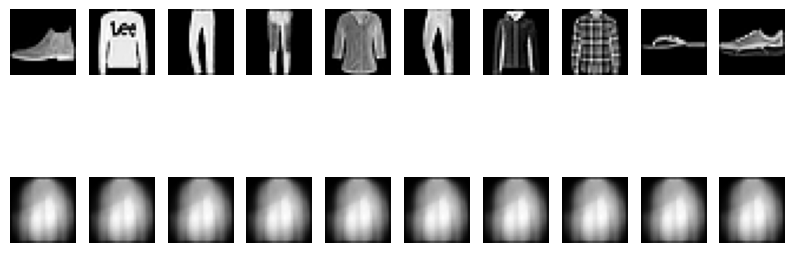

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


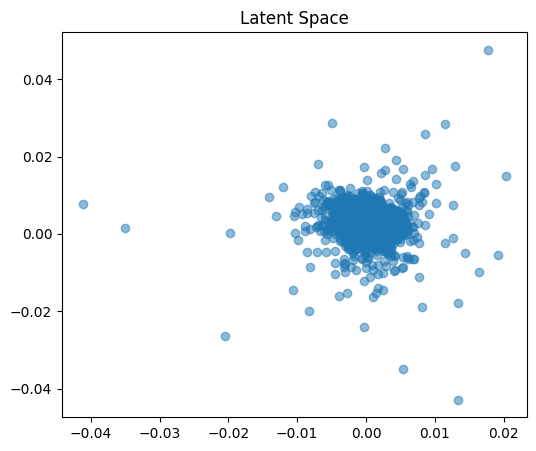

In [1]:
# 1. IMPORT LIBRARIES
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 2. LOAD DATA
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 3. MODEL PARAMETERS
input_dim = 784
latent_dim = 2

# 4. ENCODER
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(256, activation="relu")(inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

# 5. DECODER
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, outputs, name="decoder")

# 6. CUSTOM VAE
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # ✅ FIX: REQUIRED call() METHOD
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# 7. TRAIN
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
)

# 8. RECONSTRUCTION
decoded_imgs = vae.predict(x_test[:10])

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

# 9. LATENT SPACE
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(6,5))
plt.scatter(z_mean[:, 0], z_mean[:, 1], alpha=0.5)
plt.title("Latent Space")
plt.show()